# Load splitted and cleaned data test and train

In [1]:
import pandas as pd

train_df = pd.read_csv("./data/train.csv", index_col="orig_index", keep_default_na=False)
test_df  = pd.read_csv("./data/test.csv",  index_col="orig_index", keep_default_na=False)

X_train, y_train = train_df["content"], train_df["topic_id"]
X_test,  y_test  = test_df["content"],  test_df["topic_id"]

In [2]:
df = pd.read_csv("./data/selected_dataset.csv", index_col="orig_index", keep_default_na=False)
topics = pd.DataFrame({'topic_id': pd.unique(df['topic_id']), 'topic_name': pd.unique(df['topic_name'])})
topics.set_index('topic_id', inplace=True)

# Prepare pickled object dependencies

In [3]:
import pickle
import pandas as pd
import sklearn
import imblearn  # must be installed; pickle will import it as needed

In [4]:
def normalize_unicode(X):
  # try to remove 𝗜𝗻𝘀𝘁𝗮𝗴𝗿𝗮𝗺, ˢᵉᵐᵘᵃ, 𝐊𝐢𝐭𝐚, etc..
  X = X.copy()
  X = X.str.normalize('NFKC')
  return X

def remove_number(X):
  X = X.copy()
  X = X.str.replace(r"\d+", '')
  return X

def remove_feature_generated_mess(X):
  X = X.copy()
  X = X.str.replace(r"\[\[\^[(face|space)\-]{0,6}[\da-f]{8}-[\da-f]{4}-[\da-f]{4}-[\da-f]{4}-[\da-f]{12}\]\]", '')
  return X

def remove_underscore(X):
  X = X.copy()
  X = X.str.replace(r"_", ' ')
  return X

def remove_non_alphabetic(X):
  regex = r"[\u0600-\u06ff]|[\ua980-\ua9df]|[\u1b80-\u1bbf]|[\u1cc0-\u1ccf]|[\u1b00-\u1b7f]|[\u1bc0-\u1bff]|[\u4e00-\u9fff]|[\u0590-\u05ff]|[\ufb1d-\ufb4f]"
  X = X.copy()
  X = X.str.replace(regex, '')
  return X

def remove_kata_ulang(X):
  X = X.copy()
  X = X.str.replace(r"([a-z])(2)", r'\1', regex=True)
  return X

def remove_laughing(X): #TODO
  X = X.copy()
  X = X.str.replace(r"\b(?:[akiq]{0,2}[hwx]{1,2}[akiq]{0,2}){2,}h?\b", '', regex=True)
  return X

def test_print(X, payload):
  print(payload)
  return X

# Load pickled files

In [5]:
experiments = {}

In [6]:
from pathlib import Path
import re

model_dir = Path("./pickled_models")

for path in sorted(model_dir.glob("*.pkl")):
    try:
        with open(path, 'rb') as f:
            model_label = re.sub(r"^\d{8}_\d{6}_", "", path.stem)
            model_label = re.sub(r"_", " ", model_label)
            experiments[model_label] = pickle.load(f)
    except Exception as e:
        print(f"Failed to load {path.name}: {type(e).__name__}: {e}")

    
print(f"Loaded {len(experiments)} files")

Loaded 3 files


In [7]:
models = {}

for key, experiment in experiments.items():
    models[key] = experiment['search_result']

for key, model in models.items():
    print(key)
    print(model.best_score_)

MultinomialNB f1 macro
0.5855506056861788
MultinomialNB RandomUnderSampler f1 macro
0.5769877367102667
MultinomialNB RandomOverSampler f1 macro
0.6079579705404904


In [8]:
for key, model in models.items():
    print(key)
    print(model.best_params_)

MultinomialNB f1 macro
{'algo__alpha': 0.001, 'algo__fit_prior': False, 'tf_idf__ngram_range': (1, 2), 'tf_idf__use_idf': False}
MultinomialNB RandomUnderSampler f1 macro
{'algo__alpha': 1, 'algo__fit_prior': True, 'tf_idf__ngram_range': (1, 1), 'tf_idf__use_idf': True}
MultinomialNB RandomOverSampler f1 macro
{'algo__alpha': 1, 'algo__fit_prior': True, 'tf_idf__ngram_range': (1, 1), 'tf_idf__use_idf': True}


In [9]:
for key, model in models.items():
    print(key)
    print(model.score(X_train, y_train))

MultinomialNB f1 macro
0.9853650408796968
MultinomialNB RandomUnderSampler f1 macro
0.7161565366737307
MultinomialNB RandomOverSampler f1 macro
0.8651494924184261


# Evaluation

In [10]:
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, f1_score, accuracy_score
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_score, recall_score, roc_auc_score, mean_squared_error
import matplotlib.pyplot as plt

In [11]:
balanced_accuracies = {}
roc_auc_scores = {}
precisions = {}
recalls = {}
f1 = {}
y_preds = {}
y_pred_counts_arr = {}

for key, model in models.items():
  y_pred = model.predict(X_test)
  y_preds[key] = y_pred
  y_pred_prob = model.predict_proba(X_test)

  y_pred_counts_arr[key] = pd.Series(y_pred).value_counts()
  balanced_accuracies[key] = balanced_accuracy_score(y_test, y_pred)
  f1[key] = f1_score(y_test, y_pred, average='macro')
  precisions[key] = precision_score(y_test, y_pred, average='macro')
  recalls[key] = recall_score(y_test, y_pred, average='macro')
  roc_auc_scores[key] = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')

In [12]:
y_pred_counts_arr

{'MultinomialNB f1 macro': 15.0    687
 43.0    390
 11.0    288
 51.0    281
 10.0    249
 7.0     248
 14.0    203
 21.0    196
 22.0    190
 13.0    152
 31.0    141
 6.0     104
 Name: count, dtype: int64,
 'MultinomialNB RandomUnderSampler f1 macro': 15.0    577
 51.0    308
 43.0    289
 7.0     284
 22.0    259
 10.0    239
 13.0    213
 31.0    202
 6.0     200
 21.0    195
 11.0    186
 14.0    177
 Name: count, dtype: int64,
 'MultinomialNB RandomOverSampler f1 macro': 15.0    570
 43.0    320
 51.0    320
 10.0    268
 7.0     265
 22.0    245
 11.0    244
 31.0    187
 13.0    187
 14.0    186
 21.0    178
 6.0     159
 Name: count, dtype: int64}

In [13]:
models.keys()

dict_keys(['MultinomialNB f1 macro', 'MultinomialNB RandomUnderSampler f1 macro', 'MultinomialNB RandomOverSampler f1 macro'])

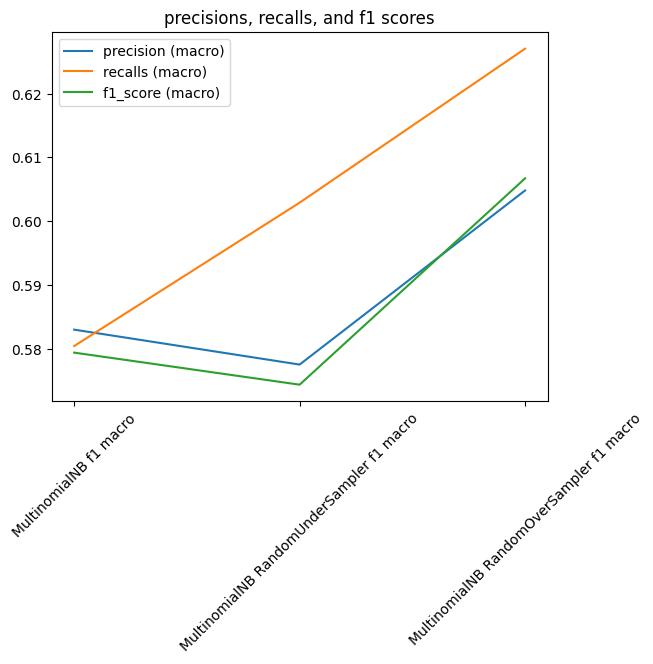

In [14]:
fig, ax = plt.subplots()
ax.plot(models.keys(), precisions.values(), label="precision (macro)")
ax.plot(models.keys(), recalls.values(), label="recalls (macro)")
ax.plot(models.keys(), f1.values(), label="f1_score (macro)")
ax.legend()
plt.title("precisions, recalls, and f1 scores")
plt.xticks(rotation=45)

plt.show()

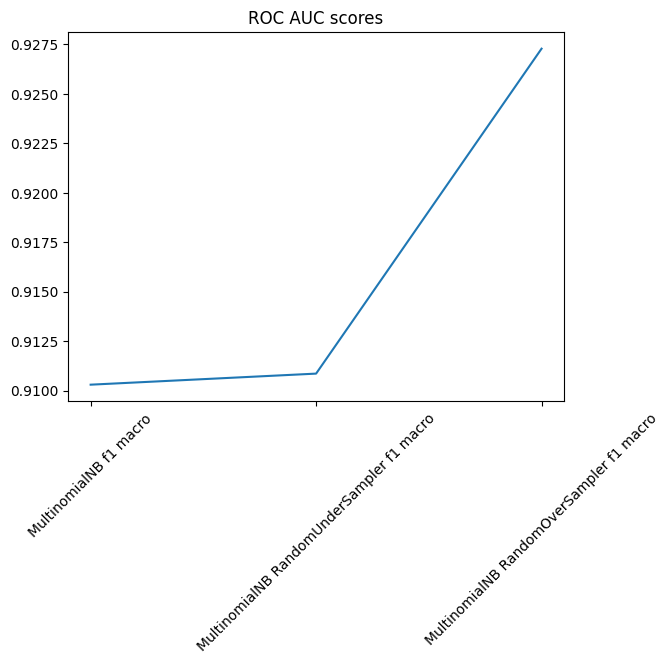

In [15]:
fig, ax = plt.subplots()
ax.plot(models.keys(), roc_auc_scores.values())
plt.title("ROC AUC scores")
plt.xticks(rotation=45)

plt.show()

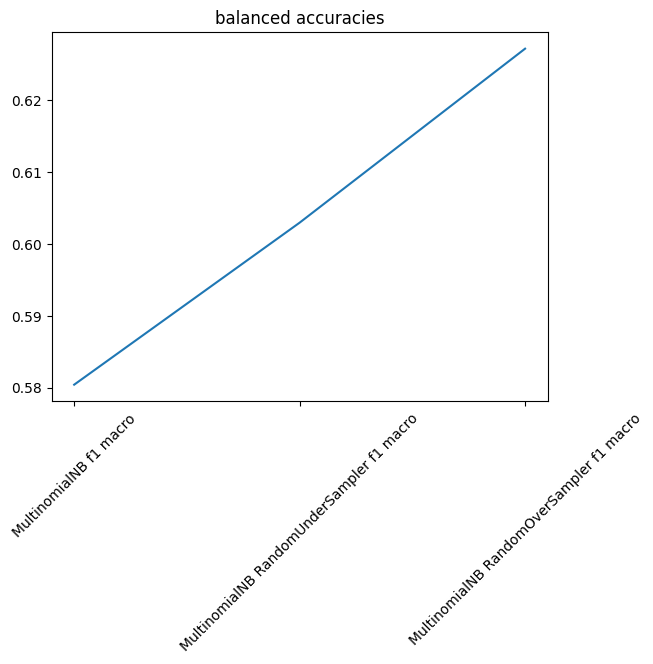

In [16]:
fig, ax = plt.subplots()
ax.plot(models.keys(), balanced_accuracies.values())
plt.title("balanced accuracies")
plt.xticks(rotation=45)

plt.show()

In [17]:
f1_scores = {}
precisions_dict = {}
recalls_dict = {}
for key, model in models.items():
  y_pred = model.predict(X_test)
  f1_scores[key] = f1_score(y_test, y_pred, average=None)
  precisions_dict[key] = precision_score(y_test, y_pred, average=None)
  recalls_dict[key] = recall_score(y_test, y_pred, average=None)

In [18]:
class_labels = [6.0, 7.0, 10.0, 11.0, 13.0, 14.0, 15.0, 21.0, 22.0, 31.0, 43.0, 51.0]
name_labels = ["Sains", "Pertanian", "Ekonomi Bisnis", "Filsafat", "Sosial Budaya", "Politik", "Psikologi", "Agama", "Pendidikan", "Sejarah", "Islam", "Kesehatan"]

In [19]:
precision_df = pd.DataFrame(precisions_dict, index=class_labels)
precision_df = precision_df.join(y_train.value_counts())
precision_df = precision_df.join(topics)

recall_df = pd.DataFrame(recalls_dict, index=class_labels)
recall_df = recall_df.join(y_train.value_counts())
recall_df = recall_df.join(topics)

f1_df = pd.DataFrame(f1_scores, index=class_labels)
f1_df = f1_df.join(y_train.value_counts())
f1_df = f1_df.join(topics)

precision_df = precision_df.sort_values(by=['count'])
recall_df = recall_df.sort_values(by=['count'])

In [20]:
display(precision_df)
display(recall_df)
display(f1_df)

,MultinomialNB f1 macro,MultinomialNB RandomUnderSampler f1 macro,MultinomialNB RandomOverSampler f1 macro,count,topic_name
6.0,0.269231,0.260000,0.276730,377,Sains
31.0,0.524823,0.455446,0.459893,493,Sejarah
13.0,0.348684,0.276995,0.342246,644,Sosial Budaya
22.0,0.684211,0.583012,0.612245,802,Pendidikan
14.0,0.684729,0.694915,0.758065,926,Politik
7.0,0.754032,0.711268,0.754717,927,Pertanian
10.0,0.682731,0.682008,0.686567,952,Ekonomi Bisnis
21.0,0.413265,0.482051,0.522472,1012,Agama
51.0,0.797153,0.740260,0.762500,1192,Kesehatan
11.0,0.565972,0.634409,0.659836,1444,Filsafat


,MultinomialNB f1 macro,MultinomialNB RandomUnderSampler f1 macro,MultinomialNB RandomOverSampler f1 macro,count,topic_name
6.0,0.297872,0.553191,0.468085,377,Sains
31.0,0.601626,0.747967,0.699187,493,Sejarah
13.0,0.329193,0.366460,0.397516,644,Sosial Budaya
22.0,0.650000,0.755000,0.750000,802,Pendidikan
14.0,0.599138,0.530172,0.607759,926,Politik
7.0,0.806034,0.870690,0.862069,927,Pertanian
10.0,0.714286,0.684874,0.773109,952,Ekonomi Bisnis
21.0,0.320158,0.371542,0.367589,1012,Agama
51.0,0.751678,0.765101,0.818792,1192,Kesehatan
11.0,0.451524,0.326870,0.445983,1444,Filsafat


,MultinomialNB f1 macro,MultinomialNB RandomUnderSampler f1 macro,MultinomialNB RandomOverSampler f1 macro,count,topic_name
6.0,0.282828,0.353741,0.347826,377,Sains
7.0,0.779167,0.782946,0.804829,927,Pertanian
10.0,0.698152,0.683438,0.727273,952,Ekonomi Bisnis
11.0,0.502311,0.431444,0.532231,1444,Filsafat
13.0,0.338658,0.315508,0.367816,644,Sosial Budaya
14.0,0.639080,0.601467,0.674641,926,Politik
15.0,0.707472,0.682927,0.734443,2283,Psikologi
21.0,0.360802,0.419643,0.431555,1012,Agama
22.0,0.666667,0.657952,0.674157,802,Pendidikan
31.0,0.560606,0.566154,0.554839,493,Sejarah


<Axes: title={'center': 'f1 score on each class'}, xlabel='topic_name'>

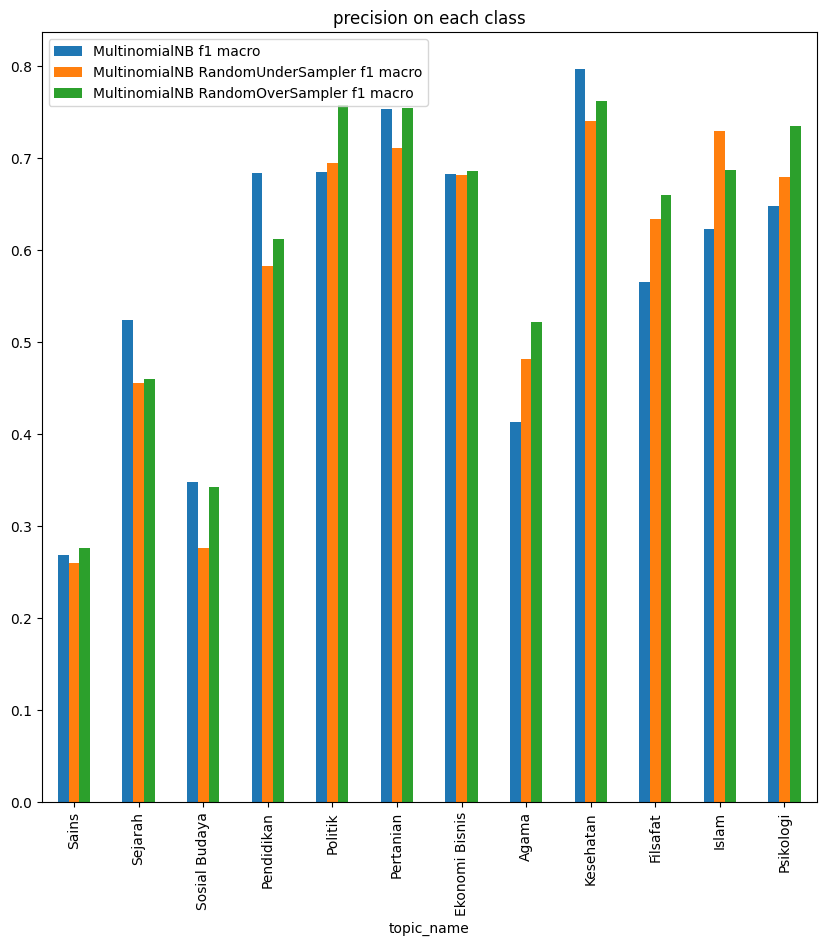

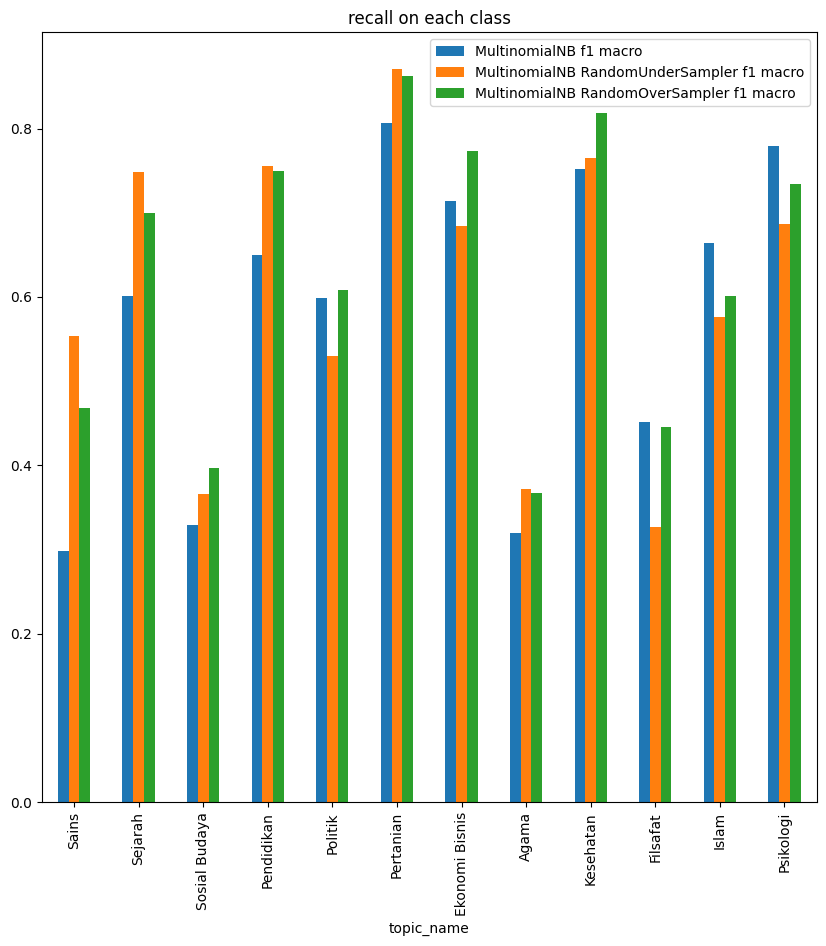

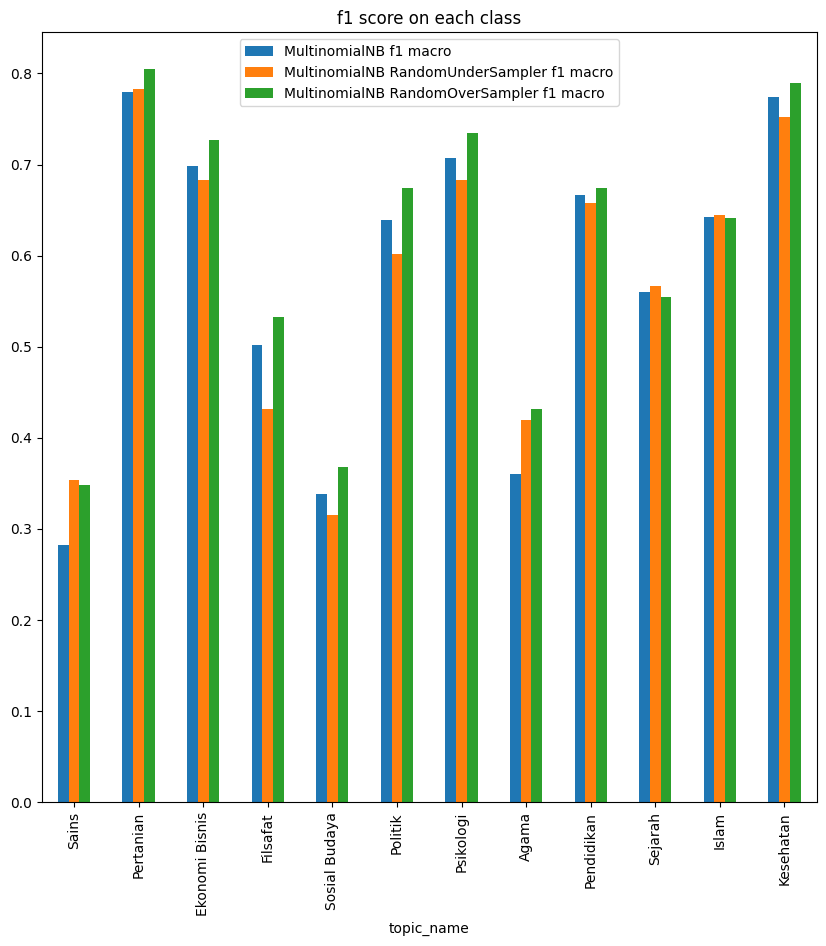

In [21]:
precision_df.drop(columns=['count']).plot(x="topic_name", kind='bar', figsize=(10, 10), title="precision on each class")
recall_df.drop(columns=['count']).plot(x="topic_name", kind='bar', figsize=(10, 10), title="recall on each class")
f1_df.drop(columns=['count']).plot(x="topic_name", kind='bar', figsize=(10, 10), title="f1 score on each class")

In [22]:
y_pred_counts_arr

{'MultinomialNB f1 macro': 15.0    687
 43.0    390
 11.0    288
 51.0    281
 10.0    249
 7.0     248
 14.0    203
 21.0    196
 22.0    190
 13.0    152
 31.0    141
 6.0     104
 Name: count, dtype: int64,
 'MultinomialNB RandomUnderSampler f1 macro': 15.0    577
 51.0    308
 43.0    289
 7.0     284
 22.0    259
 10.0    239
 13.0    213
 31.0    202
 6.0     200
 21.0    195
 11.0    186
 14.0    177
 Name: count, dtype: int64,
 'MultinomialNB RandomOverSampler f1 macro': 15.0    570
 43.0    320
 51.0    320
 10.0    268
 7.0     265
 22.0    245
 11.0    244
 31.0    187
 13.0    187
 14.0    186
 21.0    178
 6.0     159
 Name: count, dtype: int64}

In [23]:
y_pred_df = pd.DataFrame(y_pred_counts_arr, index=class_labels)
y_pred_df = y_pred_df.join(y_test.value_counts())
y_pred_df = y_pred_df.join(y_train.value_counts(), lsuffix='_test')
y_pred_df = y_pred_df.join(topics)
y_pred_df.rename(columns={'count_test': 'actual_label'}, inplace=True)
display(y_pred_df)

,MultinomialNB f1 macro,MultinomialNB RandomUnderSampler f1 macro,MultinomialNB RandomOverSampler f1 macro,actual_label,count,topic_name
6.0,104,200,159,94,377,Sains
7.0,248,284,265,232,927,Pertanian
10.0,249,239,268,238,952,Ekonomi Bisnis
11.0,288,186,244,361,1444,Filsafat
13.0,152,213,187,161,644,Sosial Budaya
14.0,203,177,186,232,926,Politik
15.0,687,577,570,571,2283,Psikologi
21.0,196,195,178,253,1012,Agama
22.0,190,259,245,200,802,Pendidikan
31.0,141,202,187,123,493,Sejarah


<Axes: title={'center': 'predicted label on each class'}, xlabel='topic_name'>

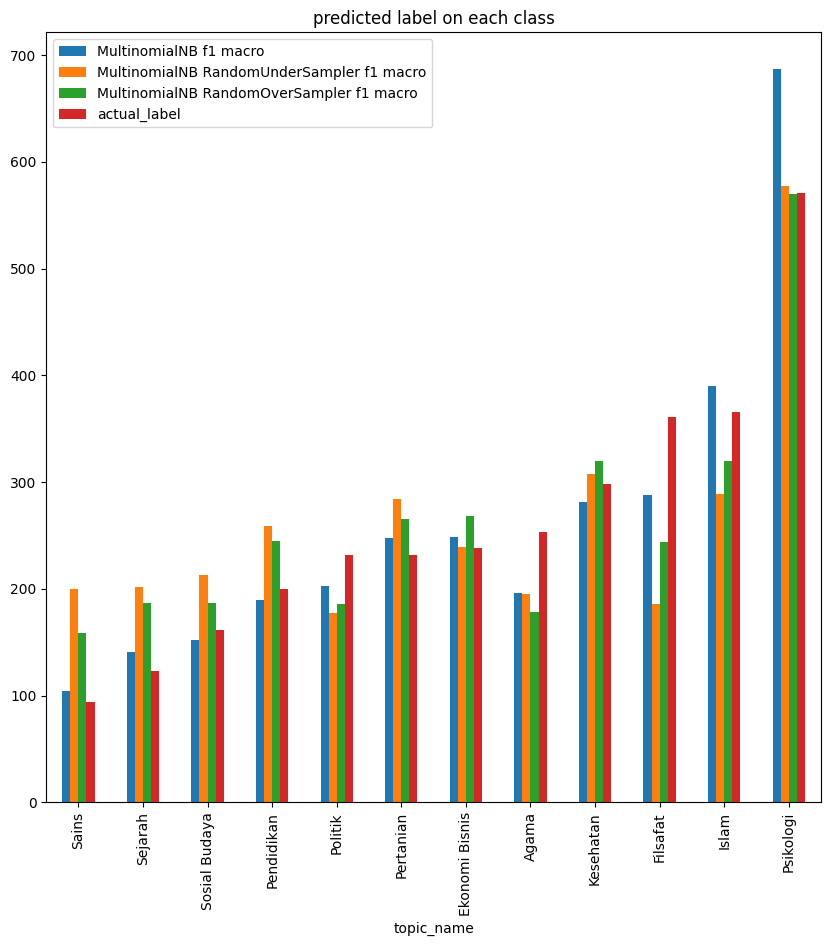

In [24]:
sorted_y_pred_df = y_pred_df.sort_values(by=['count'])
sorted_y_pred_df.drop(columns=['count']).plot(x="topic_name", kind='bar', figsize=(10, 10), title="predicted label on each class")

In [25]:
y_preds

{'MultinomialNB f1 macro': array([11., 15., 15., ..., 10., 51., 13.]),
 'MultinomialNB RandomUnderSampler f1 macro': array([31., 15., 15., ..., 10., 51., 13.]),
 'MultinomialNB RandomOverSampler f1 macro': array([31., 15., 15., ..., 10., 51., 13.])}

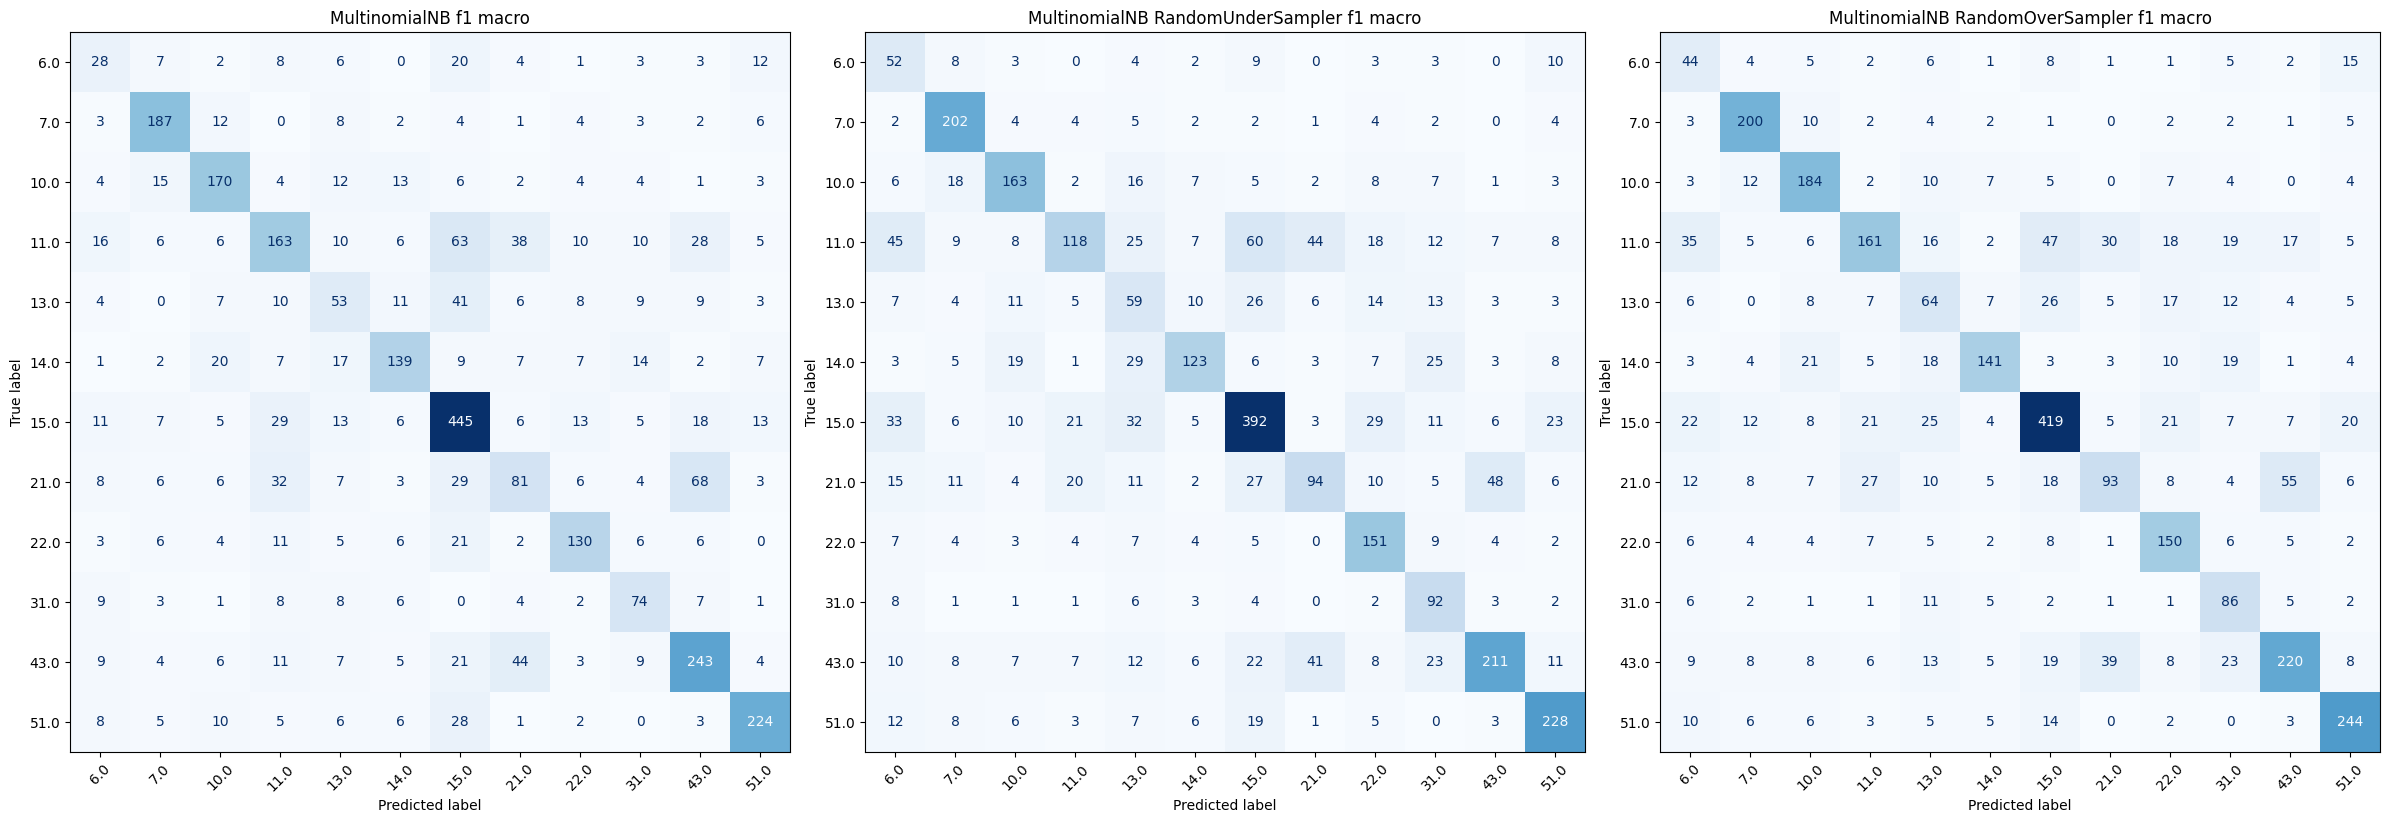

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(y_preds), figsize=(8 * len(y_preds), 8))

for ax, (key, y_pred) in zip(axes, y_preds.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        cmap=plt.cm.Blues,
        ax=ax,                     # draw on this subplot
        colorbar=False,
        xticks_rotation=45,
    )
    ax.set_title(key)

plt.tight_layout()
plt.show()

# Interface Demo

In [27]:
from ipywidgets import widgets
from IPython.display import display, clear_output, display_html, HTML
import numpy as np
from itertools import chain,cycle
import warnings
import functools
warnings.filterwarnings("ignore")

In [28]:
topics_map = {
  6.0 : "Sains",
  7.0 : "Pertanian",
  10.0 : "Ekonomi Bisnis",
  11.0 : "Filsafat",
  13.0 : "Sosial Budaya",
  14.0 : "Politik",
  15.0 : "Psikologi",
  21.0 : "Agama",
  22.0 : "Pendidikan",
  31.0 : "Sejarah",
  43.0 : "Islam",
  51.0 : "Kesehatan"
}

In [29]:
textinput = widgets.Text(placeholder='ingin menulis apa nim?', layout={'width': '100%'})

button = widgets.Button(description="Prediksi Topik")

def on_button_clicked(b):
  # Display the message within the output widget.
  with output:
    clear_output()
    input = pd.Series(data=[textinput.value])
    data_probas = []
    headers_text = []
    for key, model in models.items():
      data_pred = model.predict(input)[0]
      headers_text.append(f"{key}, prediksi: {topics_map[data_pred]}")
      data_proba = [[key, val] for key, val in dict(zip(topics_map.values(), model.predict_proba(input)[0])).items()]
      data_probas.append(
          pd.DataFrame(data_proba, columns=['topic_id', 'probability'])
          .sort_values(by='probability', ascending=False)
      )

    styler = ''
    space = "\xa0" * 10
    for i, df in enumerate(data_probas):
      df_style = df.style.set_table_attributes("style='display:inline'").set_caption(f"{key}")
      styler += df_style._repr_html_() + space

    display_html(styler, raw=True)

button.on_click(on_button_clicked)

output = widgets.Output()

form_layout = widgets.Layout(
    display='flex',
    flex_flow='row',
    justify_content='space-between',
    width='100%',
)

output_layout = widgets.Layout(
    display='flex',
    flex_flow='row',
    justify_content='space-between',
    width='100%',
)

form_items = [
    widgets.Box([textinput, button], layout=form_layout),
    widgets.Box([output], layout=output_layout)
]

form = widgets.Box(form_items, layout=widgets.Layout(
    display='flex',
    flex_flow='column',
    border='solid 2px',
    align_items='center',
    padding='50px',
    width='100%',
))
form

Box(children=(Box(children=(Text(value='', layout=Layout(width='100%'), placeholder='ingin menulis apa nim?'),…